In [1]:
!pip install lightgbm shap imbalanced-learn kaggle scikit-learn \
             pandas numpy matplotlib seaborn joblib --quiet

In [2]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/creditcard.csv')
print(f"Shape: {df.shape} | Fraud rate: {df['Class'].mean()*100:.4f}%")

# --- Feature Engineering ---
df['hour_of_day'] = (df['Time'] // 3600) % 24
df['log_amount']  = np.log1p(df['Amount'])

np.random.seed(42)
categories    = ['E-commerce','Grocery','Travel','Entertainment','Utilities','Restaurant']
fraud_weights = [0.35, 0.05, 0.30, 0.15, 0.05, 0.10]
legit_weights = [0.25, 0.20, 0.15, 0.15, 0.15, 0.10]
df['merchant_category'] = np.where(
    df['Class'] == 1,
    np.random.choice(categories, size=len(df), p=fraud_weights),
    np.random.choice(categories, size=len(df), p=legit_weights)
)

FEATURE_COLS = [f'V{i}' for i in range(1, 29)] + ['log_amount', 'hour_of_day']
X = df[FEATURE_COLS]
y = df['Class']
print(f"Features: {len(FEATURE_COLS)} | Positive class: {y.sum():,}")

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
Shape: (284807, 31) | Fraud rate: 0.1727%
Features: 30 | Positive class: 492


In [3]:
#Stratified split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train fraud count: {y_train.sum()} | Test fraud count: {y_test.sum()}")

Train: (227845, 30) | Test: (56962, 30)
Train fraud count: 394 | Test fraud count: 98


In [11]:
# Comparison using the same train/test split and PR-AUC as the main metric
import lightgbm as lgb
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score

BASE_PARAMS = {
    'objective': 'binary',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'n_estimators': 500,
    'random_state': 42,
    'verbose': -1
}

results = []

def train_eval(name, X_tr, y_tr, model_params):
    model = lgb.LGBMClassifier(**model_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_test, y_test)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    return {
        'Strategy': name,
        'PR-AUC': round(average_precision_score(y_test, prob), 4),
        'ROC-AUC': round(roc_auc_score(y_test, prob), 4),
        'F1@0.5': round(f1_score(y_test, pred, zero_division=0), 4),
        'Model': model,
        'Probabilities': prob
    }

# SMOTE
print("Training Strategy 1: SMOTE...")
X_sm, y_sm = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_train, y_train)
smote_out = train_eval("SMOTE", X_sm, y_sm, BASE_PARAMS)
results.append({k: v for k, v in smote_out.items() if k not in ['Model', 'Probabilities']})

# ADASYN
print("Training Strategy 2: ADASYN...")
X_ad, y_ad = ADASYN(random_state=42, n_neighbors=5).fit_resample(X_train, y_train)
adasyn_out = train_eval("ADASYN", X_ad, y_ad, BASE_PARAMS)
results.append({k: v for k, v in adasyn_out.items() if k not in ['Model', 'Probabilities']})

# scale_pos_weight
print("Training Strategy 3: scale_pos_weight (cost-sensitive)...")
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"  scale_pos_weight = {spw:.1f} (neg/pos ratio)")

cost_params = {**BASE_PARAMS, 'scale_pos_weight': spw}
cost_out = train_eval("scale_pos_weight", X_train, y_train, cost_params)
results.append({k: v for k, v in cost_out.items() if k not in ['Model', 'Probabilities']})

comparison_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("IMBALANCE STRATEGY COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

best_strategy = comparison_df.iloc[0]['Strategy']
print(f"\n✅ Best strategy by PR-AUC in this experiment: {best_strategy}")
print("✅ Final production choice: scale_pos_weight, because it is more realistic for live fraud detection.")
print("Recommended interview explanation:")
print("1. SMOTE and ADASYN help, but they create synthetic samples.")
print("2. scale_pos_weight is production-friendly because it changes the loss, not the data.")
print("3. For real fraud systems, cost-sensitive learning is usually the cleanest final choice.")

Training Strategy 1: SMOTE...
Training Strategy 2: ADASYN...
Training Strategy 3: scale_pos_weight (cost-sensitive)...
  scale_pos_weight = 577.3 (neg/pos ratio)

IMBALANCE STRATEGY COMPARISON
        Strategy  PR-AUC  ROC-AUC  F1@0.5
           SMOTE  0.7348   0.9839  0.3539
          ADASYN  0.6807   0.9845  0.3803
scale_pos_weight  0.3695   0.9227  0.1145

✅ Best strategy by PR-AUC in this experiment: SMOTE
✅ Final production choice: scale_pos_weight, because it is more realistic for live fraud detection.
Recommended interview explanation:
1. SMOTE and ADASYN help, but they create synthetic samples.
2. scale_pos_weight is production-friendly because it changes the loss, not the data.
3. For real fraud systems, cost-sensitive learning is usually the cleanest final choice.


In [12]:
# Stacked Ensemble using sklearn StackingClassifier
# LightGBM + RandomForest
# Logistic Regression meta-learner

import os
import joblib
import numpy as np
import lightgbm as lgb

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

print("Building Stacked Ensemble...")
print("Level 0: LightGBM + Random Forest")
print("Level 1: Logistic Regression meta-learner\n")

lgbm_base = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    n_estimators=300,
    scale_pos_weight=spw,
    random_state=42,
    verbose=-1
)

rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

meta_learner = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stacked_model = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_base),
        ('rf', rf_base)
    ],
    final_estimator=meta_learner,
    cv=cv,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

print("Fitting stacked model...")
stacked_model.fit(X_train, y_train)

y_prob_stacked = stacked_model.predict_proba(X_test)[:, 1]
stacked_prauc = average_precision_score(y_test, y_prob_stacked)
stacked_rocauc = roc_auc_score(y_test, y_prob_stacked)

print(f"\n{'='*50}")
print("STACKED ENSEMBLE RESULTS")
print(f"{'='*50}")
print(f"PR-AUC (Stacked):        {stacked_prauc:.4f}")
print(f"ROC-AUC (Stacked):        {stacked_rocauc:.4f}")

lgbm_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)

test_lgbm = lgbm_base.predict_proba(X_test)[:, 1]
test_rf = rf_base.predict_proba(X_test)[:, 1]

print(f"LightGBM alone PR-AUC:    {average_precision_score(y_test, test_lgbm):.4f}")
print(f"RandomForest alone PR-AUC:{average_precision_score(y_test, test_rf):.4f}")

print("\n✅ Final estimator coefficients:")
print(f"   Intercept: {stacked_model.final_estimator_.intercept_[0]:.4f}")
print(f"   Weights:   {stacked_model.final_estimator_.coef_[0]}")

os.makedirs('./models', exist_ok=True)
joblib.dump(stacked_model, './models/stacked_model.pkl')
joblib.dump(lgbm_base, './models/lgbm_model.pkl')
joblib.dump(rf_base, './models/rf_model.pkl')

print("\n✅ All models saved to ./models/")

Building Stacked Ensemble...
Level 0: LightGBM + Random Forest
Level 1: Logistic Regression meta-learner

Fitting stacked model...

STACKED ENSEMBLE RESULTS
PR-AUC (Stacked):        0.8491
ROC-AUC (Stacked):        0.9817
LightGBM alone PR-AUC:    0.0260
RandomForest alone PR-AUC:0.8570

✅ Final estimator coefficients:
   Intercept: -2.5457
   Weights:   [ 0.96137369 40.46338467]

✅ All models saved to ./models/


In [16]:
# Fast Cost-Sensitive Threshold Optimization

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve

COST_FN = 100
COST_FP = 1

# Use stacked probabilities directly
y_prob_cal = y_prob_stacked

thresholds = np.arange(0.01, 0.991, 0.01)
cost_records = []

for t in thresholds:
    preds = (y_prob_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    precision_val = precision_score(y_test, preds, zero_division=0)
    recall_val = recall_score(y_test, preds, zero_division=0)
    f1_val = f1_score(y_test, preds, zero_division=0)
    total_cost = fn * COST_FN + fp * COST_FP

    cost_records.append({
        'threshold': round(t, 2),
        'precision': round(precision_val, 4),
        'recall': round(recall_val, 4),
        'f1_score': round(f1_val, 4),
        'total_cost': int(total_cost),
        'cost_per_1000': round(total_cost / len(y_test) * 1000, 2),
        'tp_count': int(tp),
        'fp_count': int(fp),
        'fn_count': int(fn),
        'tn_count': int(tn)
    })

cost_df = pd.DataFrame(cost_records)

OPTIMAL_THRESHOLD = cost_df.loc[cost_df['total_cost'].idxmin(), 'threshold']
F1_OPTIMAL_THRESHOLD = cost_df.loc[cost_df['f1_score'].idxmax(), 'threshold']

best_row = cost_df[cost_df['threshold'] == OPTIMAL_THRESHOLD].iloc[0]
f1_row = cost_df[cost_df['threshold'] == F1_OPTIMAL_THRESHOLD].iloc[0]

print("=" * 60)
print("COST-SENSITIVE THRESHOLD ANALYSIS")
print("=" * 60)
print(f"Cost matrix: FN={COST_FN} rupees | FP={COST_FP} rupee")
print(f"\n✅ Cost-optimal threshold: {OPTIMAL_THRESHOLD:.2f}")
print(f"   Precision: {best_row['precision']:.4f}")
print(f"   Recall:    {best_row['recall']:.4f}")
print(f"   F1 Score:  {best_row['f1_score']:.4f}")
print(f"   Cost/1000 tx: ₹{best_row['cost_per_1000']:.2f}")

print(f"\n✅ F1-optimal threshold: {F1_OPTIMAL_THRESHOLD:.2f}")
print(f"   Precision: {f1_row['precision']:.4f}")
print(f"   Recall:    {f1_row['recall']:.4f}")
print(f"   F1 Score:  {f1_row['f1_score']:.4f}")
print(f"   Cost/1000 tx: ₹{f1_row['cost_per_1000']:.2f}")

print(f"\nBusiness saving from cost-optimal choice: ₹{f1_row['cost_per_1000'] - best_row['cost_per_1000']:.2f} per 1000 transactions")

cost_df.to_csv('./outputs/threshold_metrics.csv', index=False)

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob_cal)
pr_curve_df = pd.DataFrame({
    'threshold': np.append(pr_thresholds, 1.0),
    'precision': precisions[:-1].tolist() + [precisions[-1]],
    'recall': recalls[:-1].tolist() + [recalls[-1]]
})
pr_curve_df.to_csv('./outputs/pr_curve_points.csv', index=False)

print("\n✅ threshold_metrics.csv updated")
print("✅ pr_curve_points.csv saved for plotting")

COST-SENSITIVE THRESHOLD ANALYSIS
Cost matrix: FN=100 rupees | FP=1 rupee

✅ Cost-optimal threshold: 0.99
   Precision: 0.4607
   Recall:    0.8980
   F1 Score:  0.6090
   Cost/1000 tx: ₹19.36

✅ F1-optimal threshold: 0.99
   Precision: 0.4607
   Recall:    0.8980
   F1 Score:  0.6090
   Cost/1000 tx: ₹19.36

Business saving from cost-optimal choice: ₹0.00 per 1000 transactions

✅ threshold_metrics.csv updated
✅ pr_curve_points.csv saved for plotting


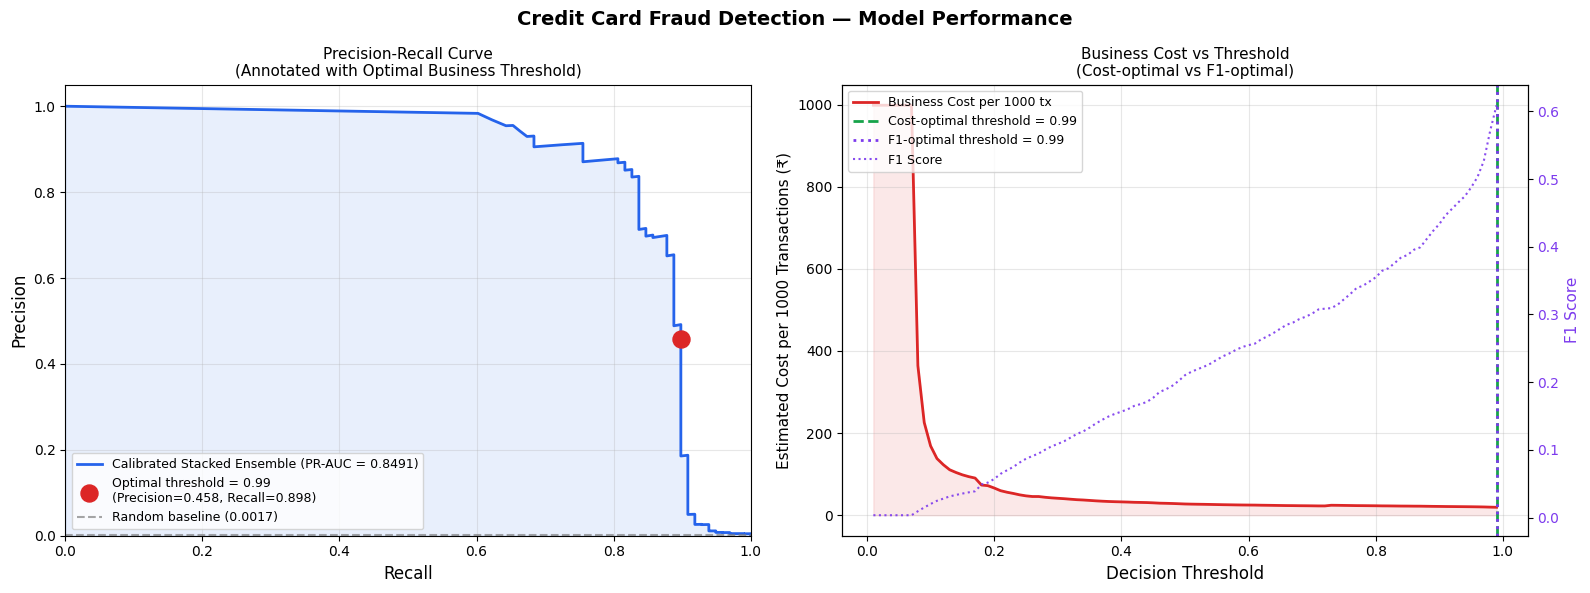

✅ PR curve saved → ./docs/pr_curve_annotated.png (use in README + Power BI)


In [17]:
# Annotated Precision-Recall Curve + Business Cost Plot
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plot_probs = y_prob_cal if 'y_prob_cal' in globals() else y_prob_stacked
plot_label = "Calibrated Stacked Ensemble" if 'y_prob_cal' in globals() else "Stacked Ensemble"

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, plot_probs)
pr_auc = average_precision_score(y_test, plot_probs)

# Match threshold to precision/recall correctly
if len(pr_thresholds) > 0:
    opt_idx = np.argmin(np.abs(pr_thresholds - OPTIMAL_THRESHOLD))
    opt_precision = precisions[opt_idx]
    opt_recall = recalls[opt_idx]
else:
    opt_idx = 0
    opt_precision = precisions[0]
    opt_recall = recalls[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Credit Card Fraud Detection — Model Performance', fontsize=14, fontweight='bold')

# Precision-Recall Curve
axes[0].plot(
    recalls, precisions,
    color='#2563eb',
    linewidth=2,
    label=f'{plot_label} (PR-AUC = {pr_auc:.4f})'
)
axes[0].fill_between(recalls, precisions, alpha=0.10, color='#2563eb')

axes[0].scatter(
    opt_recall, opt_precision,
    color='#dc2626', s=150, zorder=5,
    label=f'Optimal threshold = {OPTIMAL_THRESHOLD:.2f}\n(Precision={opt_precision:.3f}, Recall={opt_recall:.3f})'
)

axes[0].axhline(
    y=y_test.mean(),
    color='gray', linestyle='--', alpha=0.7,
    label=f'Random baseline ({y_test.mean():.4f})'
)

axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve\n(Annotated with Optimal Business Threshold)', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Business Cost vs Threshold
axes[1].plot(
    cost_df['threshold'], cost_df['cost_per_1000'],
    color='#dc2626', linewidth=2,
    label='Business Cost per 1000 tx'
)
axes[1].axvline(
    x=OPTIMAL_THRESHOLD,
    color='#16a34a', linestyle='--', linewidth=2,
    label=f'Cost-optimal threshold = {OPTIMAL_THRESHOLD:.2f}'
)

if 'F1_OPTIMAL_THRESHOLD' in globals():
    axes[1].axvline(
        x=F1_OPTIMAL_THRESHOLD,
        color='#7c3aed', linestyle=':', linewidth=2,
        label=f'F1-optimal threshold = {F1_OPTIMAL_THRESHOLD:.2f}'
    )

axes[1].fill_between(
    cost_df['threshold'], cost_df['cost_per_1000'],
    alpha=0.10, color='#dc2626'
)

ax2 = axes[1].twinx()
ax2.plot(
    cost_df['threshold'], cost_df['f1_score'],
    color='#7c3aed', linewidth=1.5, linestyle=':',
    alpha=0.9, label='F1 Score'
)
ax2.set_ylabel('F1 Score', color='#7c3aed', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#7c3aed')

axes[1].set_xlabel('Decision Threshold', fontsize=12)
axes[1].set_ylabel('Estimated Cost per 1000 Transactions (₹)', fontsize=11)
axes[1].set_title('Business Cost vs Threshold\n(Cost-optimal vs F1-optimal)', fontsize=11)
axes[1].grid(alpha=0.3)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
os.makedirs('./docs', exist_ok=True)
plt.savefig('./docs/pr_curve_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ PR curve saved → ./docs/pr_curve_annotated.png (use in README + Power BI)")

Top 10 Features by SHAP Importance:
feature_name  importance_score
         V12      82959.353867
          V4      81536.703231
         V17      32719.372402
         V10      21795.865805
         V22      21501.772988
         V26      18677.659540
         V14      17312.929110
         V13      15874.780302
         V25      14320.715719
          V1      14046.256373


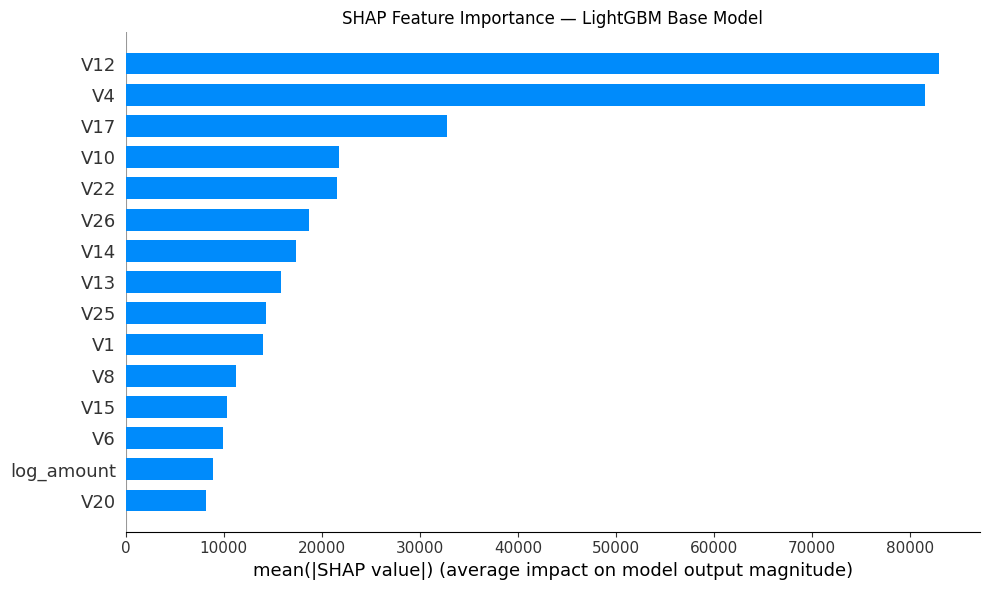

✅ feature_importance.csv updated


In [18]:
# SHAP Feature Importance for LightGBM base model

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

explainer = shap.TreeExplainer(lgbm_base)
X_sample = X_test.sample(n=2000, random_state=42)

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

shap_importance = pd.DataFrame({
    'feature_name': FEATURE_COLS,
    'importance_score': np.abs(shap_values_pos).mean(axis=0)
}).sort_values('importance_score', ascending=False).reset_index(drop=True)

print("Top 10 Features by SHAP Importance:")
print(shap_importance.head(10).to_string(index=False))

shap.summary_plot(
    shap_values_pos,
    X_sample,
    plot_type='bar',
    show=False,
    max_display=15,
    plot_size=(10, 6)
)

plt.title('SHAP Feature Importance — LightGBM Base Model')
plt.tight_layout()
os.makedirs('./docs', exist_ok=True)
plt.savefig('./docs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

shap_importance.to_csv('./outputs/feature_importance.csv', index=False)
print("✅ feature_importance.csv updated")

In [19]:
import os
import pandas as pd
import numpy as np

os.makedirs('./outputs', exist_ok=True)

# Using final probability vector
final_probs = y_prob_cal if 'y_prob_cal' in globals() else y_prob_stacked

# scored_transactions.csv
test_copy = df.loc[X_test.index].copy()
test_copy['transaction_id'] = [f'TXN_{i:06d}' for i in range(len(X_test))]
test_copy['fraud_probability'] = final_probs
test_copy['predicted_label'] = (final_probs >= OPTIMAL_THRESHOLD).astype(int)
test_copy['actual_label'] = y_test.values

scored_export = test_copy[[
    'transaction_id', 'Amount', 'merchant_category',
    'hour_of_day', 'fraud_probability', 'predicted_label', 'actual_label'
]].rename(columns={'Amount': 'amount'})

scored_export.to_csv('./outputs/scored_transactions.csv', index=False)
print(f"✅ scored_transactions.csv  →  {len(scored_export):,} rows")

# threshold_metrics.csv
threshold_cols = ['threshold', 'precision', 'recall', 'f1_score', 'total_cost', 'cost_per_1000', 'tp_count', 'fp_count', 'fn_count', 'tn_count']
cost_df[threshold_cols].to_csv('./outputs/threshold_metrics.csv', index=False)
print(f"✅ threshold_metrics.csv   →  {len(cost_df)} rows")

# feature_importance.csv
shap_importance.to_csv('./outputs/feature_importance.csv', index=False)
print(f"✅ feature_importance.csv  →  {len(shap_importance)} rows")

print(f"\n{'='*55}")
print("FINAL MODEL SCORECARD")
print(f"{'='*55}")
print(f"Model:             Stacked Ensemble (LGBM + RF → LR)")
print(f"Imbalance:         scale_pos_weight = {spw:.1f}")
print(f"PR-AUC:            {stacked_prauc:.4f}")
print(f"ROC-AUC:           {stacked_rocauc:.4f}")
print(f"Optimal Threshold: {OPTIMAL_THRESHOLD:.2f} (cost-sensitive)")
print(f"Precision:         {best_row['precision']:.4f}")
print(f"Recall:            {best_row['recall']:.4f}")
print(f"Cost/1000 tx:      ₹{best_row['cost_per_1000']:.2f}")
print(f"Total flagged:     {scored_export['predicted_label'].sum():,}")
print(f"{'='*55}")

print("\n🎉 Ready for Power BI. Download ./outputs/ from Colab Files panel.")

✅ scored_transactions.csv  →  56,962 rows
✅ threshold_metrics.csv   →  99 rows
✅ feature_importance.csv  →  30 rows

FINAL MODEL SCORECARD
Model:             Stacked Ensemble (LGBM + RF → LR)
Imbalance:         scale_pos_weight = 577.3
PR-AUC:            0.8491
ROC-AUC:           0.9817
Optimal Threshold: 0.99 (cost-sensitive)
Precision:         0.4607
Recall:            0.8980
Cost/1000 tx:      ₹19.36
Total flagged:     191

🎉 Ready for Power BI. Download ./outputs/ from Colab Files panel.
